<a href="https://colab.research.google.com/github/tekuugr-0205-16-hub/robust-recursive-svm-tree/blob/main/Robust_Recursive_SVM_Tree1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Plot settings
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "DejaVu Sans"
})

SEED = 42
np.random.seed(SEED)



In [ ]:

data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

print("\nClass distribution:")
print(df["target"].value_counts())

Dataset shape: (569, 31)
Missing values: 0

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,pca_1,pca_2
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,5.690000e+02,5.690000e+02
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417,4.995028e-17,4.995028e-17
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918,3.647601e+00,2.387755e+00
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000,-5.565736e+00,-7.775853e+00
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000,-2.757430e+00,-1.499825e+00
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000,-1.173831e+00,-1.959558e-01
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000,2.508766e+00,1.228297e+00
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000,1.631923e+01,1.257319e+01


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

Explained variance by first 2 components: 63.24%


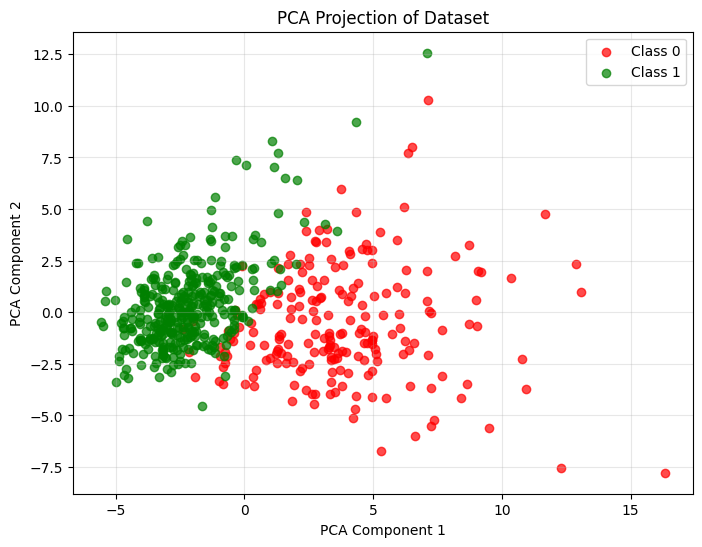

In [ ]:

X_full = df.drop("target", axis=1)
y = df["target"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# PCA only for visualization
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100

print(
    f"Explained variance by first 2 components: "
    f"{sum(explained):.2f}%"
)

# Store PCA values for plotting
df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]

# Scatter plot
plt.figure(figsize=(8, 6))

for label, color in zip([0, 1], ["red", "green"]):
    mask = df["target"] == label

    plt.scatter(
        df.loc[mask, "pca_1"],
        df.loc[mask, "pca_2"],
        c=color,
        alpha=0.7,
        label=f"Class {label}"
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection of Dataset")
plt.legend()

plt.show()

In [ ]:

# Raw feature matrix
X_raw = df.drop("target", axis=1).values
y = df["target"].values

# Split BEFORE scaling
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Scale using training data only
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)

X_test = scaler.transform(X_test_raw)

print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))


def inject_label_noise(y_data, noise_rate=0.15, seed=42):
    """
    Randomly flip a percentage of class labels.
    """

    rng = np.random.RandomState(seed)

    y_noisy = y_data.copy()

    n_flips = int(len(y_noisy) * noise_rate)

    flip_idx = rng.choice(
        len(y_noisy),
        n_flips,
        replace=False
    )

    y_noisy[flip_idx] = 1 - y_noisy[flip_idx]

    return y_noisy


def inject_feature_outliers(
    X_data,
    outlier_rate=0.10,
    scale=5.0,
    seed=42
):
    """
    Add random feature outliers to part of the dataset.
    """

    rng = np.random.RandomState(seed)

    X_noisy = X_data.copy()

    n_outliers = int(len(X_noisy) * outlier_rate)

    outlier_idx = rng.choice(
        len(X_noisy),
        n_outliers,
        replace=False
    )

    X_noisy[outlier_idx] += (
        rng.randn(n_outliers, X_noisy.shape[1]) * scale
    )

    return X_noisy


# Apply noise to training data only
y_train_noisy = inject_label_noise(
    y_train,
    noise_rate=0.15
)

X_train_noisy = inject_feature_outliers(
    X_train,
    outlier_rate=0.10
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nNoise configuration:")
print("- Label noise: 15%")
print("- Feature outliers: 10%")

Training samples : 455
Testing samples  : 114
Training samples: 455
Test samples: 114

Noise configuration:
- Label noise: 15%
- Feature outliers: 10%


In [ ]:

# Baseline Decision Tree
# same constraints as hybrid — fair comparison
baseline_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=8,
    random_state=SEED
)

baseline_tree.fit(
    X_train_noisy,
    y_train_noisy
)

# Predictions
y_pred_base = baseline_tree.predict(X_test)

# Metrics
base_acc = accuracy_score(
    y_test,
    y_pred_base
)

base_auc = roc_auc_score(
    y_test,
    baseline_tree.predict_proba(X_test)[:, 1]
)

print("Baseline Decision Tree Results")


print(f"Accuracy : {base_acc:.4f}")
print(f"AUC Score: {base_auc:.4f}")
print(f"Tree Depth: {baseline_tree.get_depth()}")

Baseline Decision Tree Results
Accuracy : 0.8947
AUC Score: 0.9368
Tree Depth: 4


In [ ]:

# Hybrid SVM Tree Definition


class Node:
    """
    Node structure used in the HybridSVMTree.
    """

    def __init__(self, depth=0):

        self.depth = depth

        self.is_leaf = False

        self.label = None
        self.confidence = None

        self.svm_splitter = None

        self.left = None
        self.right = None


class HybridSVMTree:
    """
    Hybrid Decision Tree using LinearSVC at each node. Instead of feature-threshold splits, each internal node
    uses a linear SVM to partition the data.The objective is to improve robustness under noisy
    training conditions.
    """

    def __init__(
        self,
        max_depth=4,
        min_samples_split=8,
        C=0.5
    ):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.C = C

        self.root = None

        self.n_nodes = 0
        self.n_leaves = 0


    def fit(self, X, y):

        self.root = self._build_tree(
            X,
            y,
            depth=0
        )

        return self


    def _build_tree(self, X, y, depth):

        self.n_nodes += 1

        node = Node(depth=depth)

        counts = Counter(y)

        majority = counts.most_common(1)[0][0]

        confidence = counts[majority] / len(y)

        # Stopping conditions
        if (
            depth >= self.max_depth or
            len(y) < self.min_samples_split or
            len(np.unique(y)) == 1
        ):

            node.is_leaf = True
            node.label = majority
            node.confidence = confidence

            self.n_leaves += 1

            return node

        # Train Linear SVM
        svm = LinearSVC(
            C=self.C,
            random_state=SEED,
            dual=False,
            max_iter=2000
        )

        try:
            svm.fit(X, y)

        except Exception:

            node.is_leaf = True
            node.label = majority
            node.confidence = confidence

            self.n_leaves += 1

            return node

        predictions = svm.predict(X)

        left_mask = (predictions == 0)
        right_mask = (predictions == 1)

        # Avoid invalid splits
        if left_mask.sum() == 0 or right_mask.sum() == 0:

            node.is_leaf = True
            node.label = majority
            node.confidence = confidence

            self.n_leaves += 1

            return node

        node.svm_splitter = svm

        # Recursive split
        node.left = self._build_tree(
            X[left_mask],
            y[left_mask],
            depth + 1
        )

        node.right = self._build_tree(
            X[right_mask],
            y[right_mask],
            depth + 1
        )

        return node


    def predict(self, X):

        return np.array([
            self._traverse(x.reshape(1, -1), self.root)
            for x in X
        ])


    def predict_proba(self, X):

        return np.array([
            self._traverse_proba(x.reshape(1, -1), self.root)
            for x in X
        ])


    def _traverse(self, x, node):

        if node.is_leaf:
            return node.label

        direction = node.svm_splitter.predict(x)[0]

        if direction == 0:
            return self._traverse(x, node.left)

        return self._traverse(x, node.right)


    def _traverse_proba(self, x, node):

        if node.is_leaf:

            if node.label == 1:
                return node.confidence

            return 1 - node.confidence

        direction = node.svm_splitter.predict(x)[0]

        if direction == 0:
            return self._traverse_proba(x, node.left)

        return self._traverse_proba(x, node.right)


    def summary(self):

        print("Hybrid Tree Summary")
        print("-" * 30)

        print(f"Max depth        : {self.max_depth}")
        print(f"Total nodes      : {self.n_nodes}")
        print(f"Leaf nodes       : {self.n_leaves}")
        print(f"SVM C parameter  : {self.C}")
        print(f"Min samples split: {self.min_samples_split}")

In [ ]:

# Train and Evaluate the Hybrid Model
# Initialize the hybrid model
hybrid_tree = HybridSVMTree(
    max_depth=4,
    min_samples_split=8,
    C=0.5
)
# Train on noisy training data
hybrid_tree.fit(
    X_train_noisy,
    y_train_noisy
)

# Predictions
y_pred_hybrid = hybrid_tree.predict(X_test)

# Confidence scores for ROC/AUC
y_proba_hybrid = hybrid_tree.predict_proba(X_test)

# Evaluation metrics
hybrid_acc = accuracy_score(
    y_test,
    y_pred_hybrid
)

hybrid_auc = roc_auc_score(
    y_test,
    y_proba_hybrid
)

print("Hybrid SVM Tree Results")


hybrid_tree.summary()

print(f"\nAccuracy : {hybrid_acc:.4f}")
print(f"AUC Score: {hybrid_auc:.4f}")

print(
    f"\nAccuracy improvement over baseline: "
    f"{(hybrid_acc - base_acc)*100:.2f}%"
)

Hybrid SVM Tree Results
Hybrid Tree Summary
------------------------------
Max depth        : 4
Total nodes      : 9
Leaf nodes       : 5
SVM C parameter  : 0.5
Min samples split: 8

Accuracy : 0.9737
AUC Score: 0.9742

Accuracy improvement over baseline: 7.89%


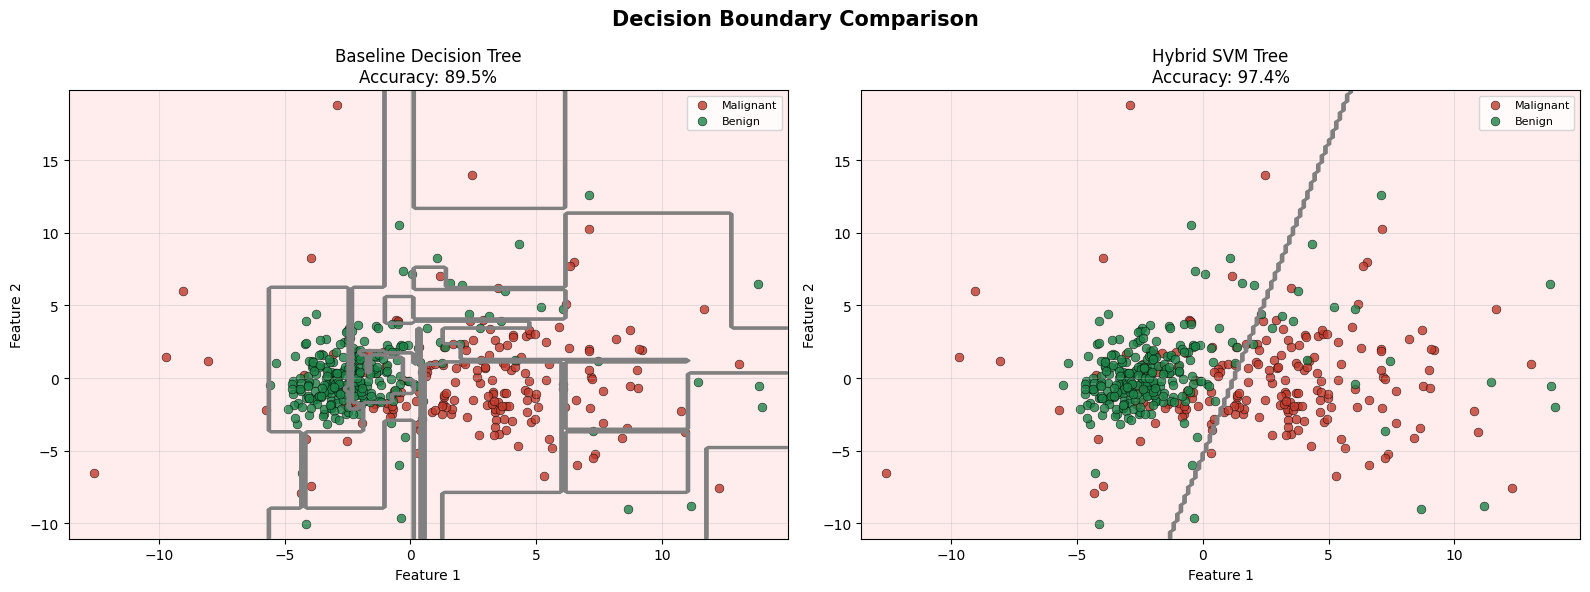

In [ ]:

#Decision Boundary Comparison


def plot_decision_boundary(
    ax,
    model,
    X,
    y,
    title,
    subtitle=""
):
    """
    Plot model decision regions and training samples.
    """

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = model.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    # Background decision regions
    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.35,
        colors=['#FFCCCC', '#CCFFDD']
    )

    # Decision boundary
    ax.contour(
        xx,
        yy,
        Z,
        colors='gray',
        linewidths=1
    )

    # Plot training samples
    for label, color, name in [
        (0, '#C0392B', 'Malignant'),
        (1, '#1D8348', 'Benign')
    ]:

        mask = (y == label)

        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            c=color,
            s=40,
            edgecolors='k',
            linewidths=0.4,
            alpha=0.8,
            label=name
        )

    ax.set_title(f"{title}\n{subtitle}")

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

    ax.legend(fontsize=8)


# Use PCA features only for visualization
X_vis = df[['pca_1', 'pca_2']].values

# Separate noisy visualization training data
X_train_vis, _, y_train_vis, _ = train_test_split(
    X_vis,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_train_vis_noisy = inject_feature_outliers(
    X_train_vis,
    outlier_rate=0.10
)

# Train visualization models on PCA data
baseline_vis = DecisionTreeClassifier(
    random_state=SEED
)

baseline_vis.fit(
    X_train_vis_noisy,
    y_train_noisy
)

hybrid_vis = HybridSVMTree(
    max_depth=4,
    min_samples_split=8,
    C=0.5
)

hybrid_vis.fit(
    X_train_vis_noisy,
    y_train_noisy
)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    "Decision Boundary Comparison",
    fontsize=15,
    fontweight='bold'
)

plot_decision_boundary(
    axes[0],
    baseline_vis,
    X_train_vis_noisy,
    y_train_noisy,
    "Baseline Decision Tree",
    f"Accuracy: {base_acc*100:.1f}%"
)

plot_decision_boundary(
    axes[1],
    hybrid_vis,
    X_train_vis_noisy,
    y_train_noisy,
    "Hybrid SVM Tree",
    f"Accuracy: {hybrid_acc*100:.1f}%"
)

plt.tight_layout()

plt.savefig(
    "02_decision_boundaries.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

Running robustness evaluation...

Noise 0% | Baseline: 92.75% | Hybrid: 95.82%
Noise 5% | Baseline: 94.07% | Hybrid: 95.38%
Noise 10% | Baseline: 90.55% | Hybrid: 95.82%
Noise 15% | Baseline: 91.21% | Hybrid: 96.04%
Noise 20% | Baseline: 90.77% | Hybrid: 95.16%
Noise 25% | Baseline: 88.79% | Hybrid: 92.09%
Noise 30% | Baseline: 86.15% | Hybrid: 90.33%
Noise 35% | Baseline: 88.57% | Hybrid: 89.23%
Noise 40% | Baseline: 87.03% | Hybrid: 85.71%


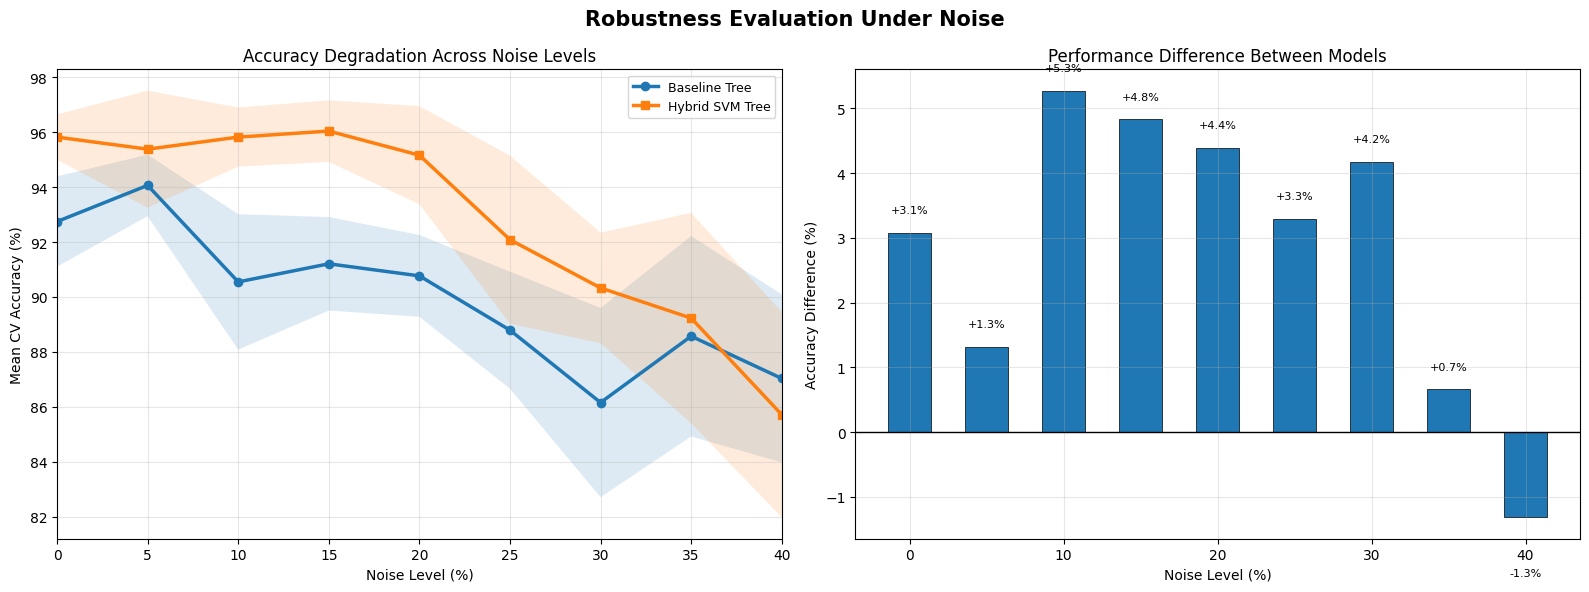

In [ ]:

#Robustness Evaluation


print("Running robustness evaluation...\n")

noise_levels = [
    0.00,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40
]

base_scores = []
hybrid_scores = []

base_stds = []
hybrid_stds = []

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

for noise in noise_levels:

    baseline_fold_scores = []
    hybrid_fold_scores = []

    for train_idx, val_idx in kf.split(X_train, y_train):


        Xtr, Xval = X_train[train_idx], X_train[val_idx]
        ytr, yval = y_train[train_idx], y_train[val_idx]

        # Apply noise to training split only
        ytr_noisy = inject_label_noise(
            ytr,
            noise_rate=noise
        )

        Xtr_noisy = inject_feature_outliers(
            Xtr,
            outlier_rate=noise / 2
        )

        # Baseline model
        baseline_model = DecisionTreeClassifier(max_depth=4,min_samples_split=8,random_state=SEED
)

        baseline_model.fit(
            Xtr_noisy,
            ytr_noisy
        )

        baseline_pred = baseline_model.predict(Xval)

        baseline_fold_scores.append(
            accuracy_score(yval, baseline_pred)
        )

        # Hybrid model
        hybrid_model = HybridSVMTree(
            max_depth=4,
            min_samples_split=8,
            C=0.5
        )

        hybrid_model.fit(
            Xtr_noisy,
            ytr_noisy
        )

        hybrid_pred = hybrid_model.predict(Xval)

        hybrid_fold_scores.append(
            accuracy_score(yval, hybrid_pred)
        )

    base_scores.append(
        np.mean(baseline_fold_scores)
    )

    hybrid_scores.append(
        np.mean(hybrid_fold_scores)
    )

    base_stds.append(
        np.std(baseline_fold_scores)
    )

    hybrid_stds.append(
        np.std(hybrid_fold_scores)
    )

    print(
        f"Noise {noise*100:.0f}% | "
        f"Baseline: {np.mean(baseline_fold_scores)*100:.2f}% | "
        f"Hybrid: {np.mean(hybrid_fold_scores)*100:.2f}%"
    )

noise_pct = [n * 100 for n in noise_levels]

base_arr = np.array(base_scores)
hybrid_arr = np.array(hybrid_scores)

base_std_arr = np.array(base_stds)
hybrid_std_arr = np.array(hybrid_stds)

# Robustness Curves


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    "Robustness Evaluation Under Noise",
    fontsize=15,
    fontweight='bold'
)
# Accuracy Curves
ax = axes[0]

ax.plot(
    noise_pct,
    base_arr * 100,
    'o-',
    linewidth=2.5,
    label='Baseline Tree'
)

ax.fill_between(
    noise_pct,
    (base_arr - base_std_arr) * 100,
    (base_arr + base_std_arr) * 100,
    alpha=0.15
)

ax.plot(
    noise_pct,
    hybrid_arr * 100,
    's-',
    linewidth=2.5,
    label='Hybrid SVM Tree'
)

ax.fill_between(
    noise_pct,
    (hybrid_arr - hybrid_std_arr) * 100,
    (hybrid_arr + hybrid_std_arr) * 100,
    alpha=0.15
)

ax.set_xlabel("Noise Level (%)")
ax.set_ylabel("Mean CV Accuracy (%)")

ax.set_title(
    "Accuracy Degradation Across Noise Levels"
)

ax.legend(fontsize=9)

ax.set_xlim(0, 40)

# Performance Gap
ax = axes[1]

gap = (
    hybrid_arr - base_arr
) * 100

bars = ax.bar(
    noise_pct,
    gap,
    edgecolor='black',
    linewidth=0.5,
    width=2.8
)

for bar, val in zip(bars, gap):

    label = (
        f"+{val:.1f}%"
        if val >= 0
        else f"{val:.1f}%"
    )

    y_pos = (
        bar.get_height() + 0.3
        if val >= 0
        else bar.get_height() - 0.9
    )

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        label,
        ha='center',
        fontsize=8
    )

ax.axhline(0, color='black', linewidth=1)

ax.set_xlabel("Noise Level (%)")
ax.set_ylabel("Accuracy Difference (%)")

ax.set_title(
    "Performance Difference Between Models"
)

plt.tight_layout()

plt.savefig(
    "03_robustness_curves.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

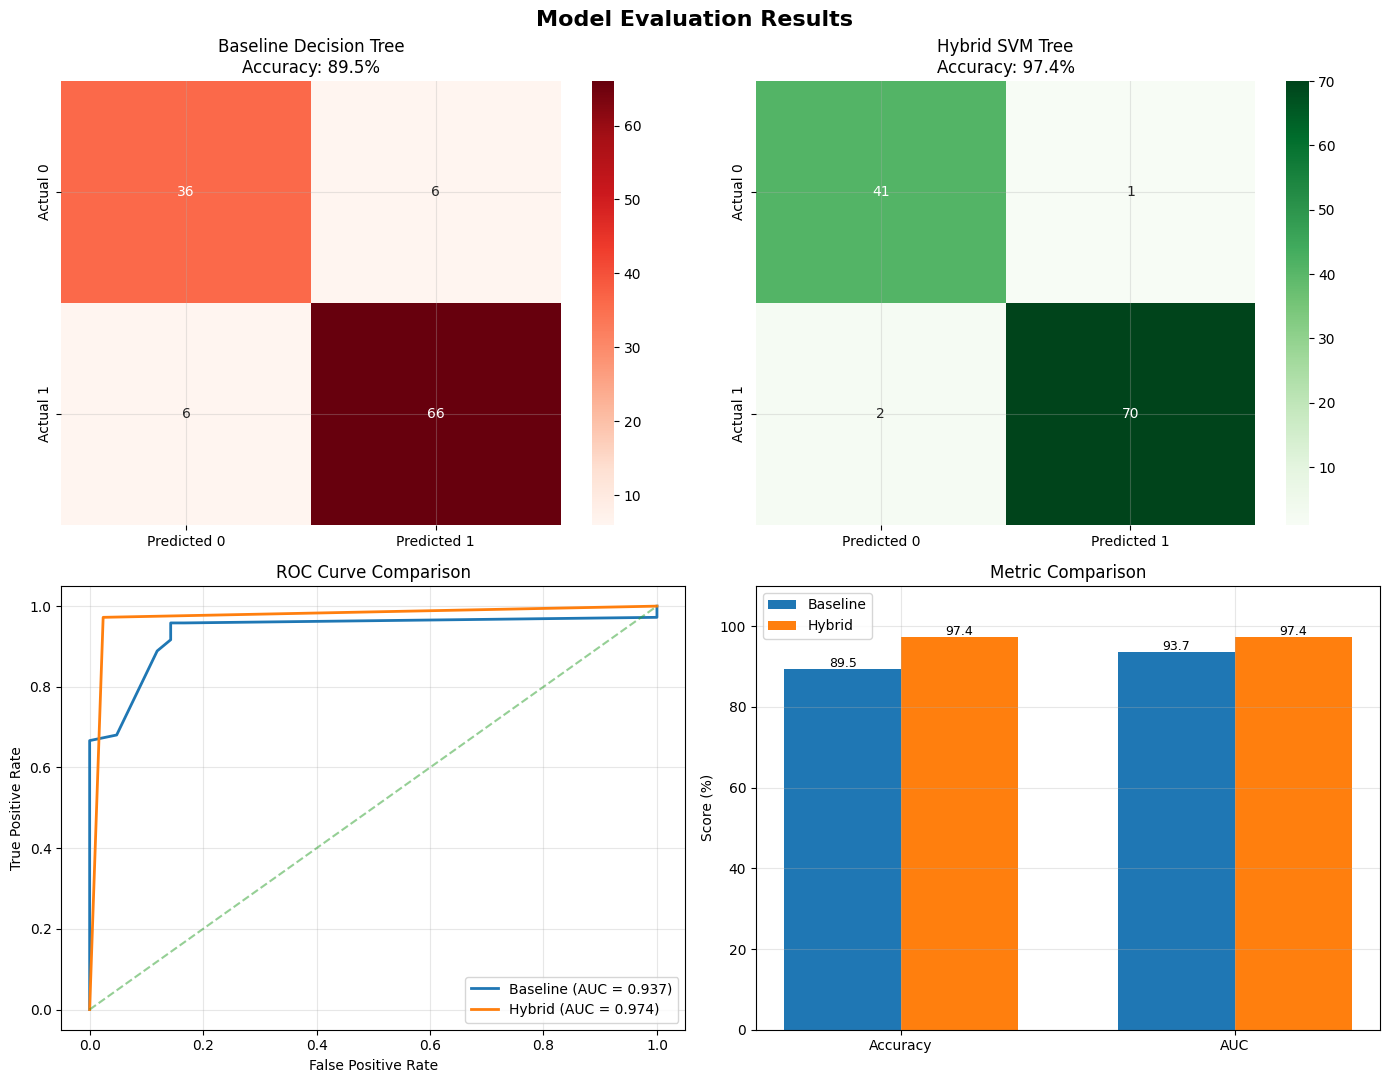

In [ ]:

#Evaluation Dashboard
# Probability scores for ROC curve
y_proba_base = baseline_tree.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

fig.suptitle(
    "Model Evaluation Results",
    fontsize=16,
    fontweight='bold'
)

# Confusion Matrix - Baseline

ax = axes[0][0]

cm_base = confusion_matrix(
    y_test,
    y_pred_base
)

sns.heatmap(
    cm_base,
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=ax,
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

ax.set_title(
    f"Baseline Decision Tree\nAccuracy: {base_acc*100:.1f}%"
)


# Confusion Matrix - Hybrid


ax = axes[0][1]

cm_hybrid = confusion_matrix(
    y_test,
    y_pred_hybrid
)

sns.heatmap(
    cm_hybrid,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=ax,
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

ax.set_title(
    f"Hybrid SVM Tree\nAccuracy: {hybrid_acc*100:.1f}%"
)


# ROC Curve Comparison
ax = axes[1][0]

fpr_base, tpr_base, _ = roc_curve(
    y_test,
    y_proba_base
)

fpr_hybrid, tpr_hybrid, _ = roc_curve(
    y_test,
    y_proba_hybrid
)

ax.plot(
    fpr_base,
    tpr_base,
    linewidth=2,
    label=f'Baseline (AUC = {base_auc:.3f})'
)

ax.plot(
    fpr_hybrid,
    tpr_hybrid,
    linewidth=2,
    label=f'Hybrid (AUC = {hybrid_auc:.3f})'
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    alpha=0.5
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.set_title("ROC Curve Comparison")

ax.legend()


# Metric Comparison
ax = axes[1][1]

metrics = ['Accuracy', 'AUC']

baseline_values = [
    base_acc * 100,
    base_auc * 100
]

hybrid_values = [
    hybrid_acc * 100,
    hybrid_auc * 100
]

x = np.arange(len(metrics))

width = 0.35

bars1 = ax.bar(
    x - width/2,
    baseline_values,
    width,
    label='Baseline'
)

bars2 = ax.bar(
    x + width/2,
    hybrid_values,
    width,
    label='Hybrid'
)

for bars in [bars1, bars2]:

    for bar in bars:

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}",
            ha='center',
            fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylabel("Score (%)")

ax.set_ylim(0, 110)

ax.set_title("Metric Comparison")

ax.legend()

plt.tight_layout()

plt.savefig(
    "04_evaluation_dashboard.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [ ]:

#Classification Reports
print("\nBaseline Decision Tree")
print(f"Accuracy : {base_acc:.4f}")
print(f"AUC Score: {base_auc:.4f}\n")

print(
    classification_report(
        y_test,
        y_pred_base,
        target_names=[
            "Malignant",
            "Benign"
        ],
        digits=4
    )
)

print("\nHybrid SVM Tree")
print("-" * 35)

print(f"Accuracy : {hybrid_acc:.4f}")
print(f"AUC Score: {hybrid_auc:.4f}\n")

print(
    classification_report(
        y_test,
        y_pred_hybrid,
        target_names=[
            "Malignant",
            "Benign"
        ],
        digits=4
    )
)

print("\nPerformance Difference")
print(
    f"Accuracy Improvement: "
    f"{(hybrid_acc - base_acc)*100:.2f}%"
)

print(
    f"AUC Improvement: "
    f"{(hybrid_auc - base_auc)*100:.2f}%"
)


Baseline Decision Tree
Accuracy : 0.8947
AUC Score: 0.9368

              precision    recall  f1-score   support

   Malignant     0.8571    0.8571    0.8571        42
      Benign     0.9167    0.9167    0.9167        72

    accuracy                         0.8947       114
   macro avg     0.8869    0.8869    0.8869       114
weighted avg     0.8947    0.8947    0.8947       114


Hybrid SVM Tree
-----------------------------------
Accuracy : 0.9737
AUC Score: 0.9742

              precision    recall  f1-score   support

   Malignant     0.9535    0.9762    0.9647        42
      Benign     0.9859    0.9722    0.9790        72

    accuracy                         0.9737       114
   macro avg     0.9697    0.9742    0.9719       114
weighted avg     0.9740    0.9737    0.9737       114


Performance Difference
Accuracy Improvement: 7.89%
AUC Improvement: 3.74%


In [ ]:

#Final Summary
print("\nFinal Project Summary")
print("\nModel:")
print("Hybrid Decision Tree using LinearSVC node partitioning")

print("\nObjective:")
print(
    "Evaluate whether margin-based node splitting "
    "improves robustness under noisy training conditions."
)

print("\nDataset:")
print("Breast Cancer Wisconsin Dataset")

print("\nNoise Conditions:")
print("- 15% label noise")
print("- 10% feature outliers")

print("\nModel Configuration:")
print("- max_depth = 4")
print("- min_samples_split = 8")
print("- LinearSVC C = 0.5")

print("\nResults:")
print(
    f"Baseline Accuracy : {base_acc*100:.2f}%"
)

print(
    f"Hybrid Accuracy   : {hybrid_acc*100:.2f}%"
)

print(
    f"Baseline AUC      : {base_auc*100:.2f}%"
)

print(
    f"Hybrid AUC        : {hybrid_auc*100:.2f}%"
)

print("\nGenerated Files:")
print("- 01_data_landscape.png")
print("- 02_decision_boundaries.png")
print("- 03_robustness_curves.png")
print("- 04_evaluation_dashboard.png")


Final Project Summary

Model:
Hybrid Decision Tree using LinearSVC node partitioning

Objective:
Evaluate whether margin-based node splitting improves robustness under noisy training conditions.

Dataset:
Breast Cancer Wisconsin Dataset

Noise Conditions:
- 15% label noise
- 10% feature outliers

Model Configuration:
- max_depth = 4
- min_samples_split = 8
- LinearSVC C = 0.5

Results:
Baseline Accuracy : 89.47%
Hybrid Accuracy   : 97.37%
Baseline AUC      : 93.68%
Hybrid AUC        : 97.42%

Generated Files:
- 01_data_landscape.png
- 02_decision_boundaries.png
- 03_robustness_curves.png
- 04_evaluation_dashboard.png
